# BCI IV-2a — Real EEG Alignment + FBCSP Diagnostic/Fix

This notebook is the next diagnostic stage after the preprocessing/FBCSP audit.

**Why this stage exists**

The current A01 results are:
- FBCSP+LDA ≈ 33.51%
- CRNN-only ≈ 41.49%

The important conclusion is that we should **not immediately tune the neural network**. First we must determine whether:
1. the T/E trial ordering and labels are aligned;
2. the real EEG contains class-discriminative MI information in a controlled within-subject experiment;
3. the FBCSP implementation behaves sensibly;
4. the LOSO drop is genuinely subject-shift rather than an extraction/label problem.

This notebook therefore adds:
- explicit T/E trial-alignment checks;
- A01 within-session classification sanity test;
- A01 T→E cross-session sanity test;
- class-wise PSD/ERD checks around C3/Cz/C4;
- two FBCSP variants for comparison:
  * normalized log-variance (current paper-style implementation)
  * log-variance without relative-power normalization;
- optional regularized CSP covariance;
- feature-count sweep before LASSO;
- a clean report for deciding whether the next problem is **data alignment**, **FBCSP**, or **CRNN**.

Do not enable full 9-subject training until this notebook passes the alignment sanity tests.


In [1]:
# ============================================================
# CELL 1 — IMPORTS / CONFIG
# ============================================================

import os, re, json, random, warnings, time
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.signal as signal
from scipy.linalg import eigh

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, balanced_accuracy_score, cohen_kappa_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import mne

warnings.filterwarnings("ignore")

SEED = 42
FS = 250
N_CHANNELS = 22
N_TIME = 1000
CLASS_NAMES = ["Left Hand", "Right Hand", "Feet", "Tongue"]
EVENT_TO_CLASS = {769: 0, 770: 1, 771: 2, 772: 3}
TRIAL_START_CODE = 768
EVAL_UNKNOWN_EVENT = 783

BANDS = [
    (1,4), (4,8), (8,12), (12,16), (16,20),
    (20,24), (24,28), (28,32), (32,35), (35,38)
]

CHANNEL_NAMES = [
    "Fz","FC3","FC1","FCz","FC2","FC4","C5","C3","C1","Cz","C2",
    "C4","C6","CP3","CP1","CPz","CP2","CP4","P3","P1","Pz","P2"
]

def reset_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)

reset_seed(SEED)

DATA_ROOT_CANDIDATES = [
    Path.cwd() / "BCI IV-2a",
    Path.cwd() / "BCI_IV-2a",
    Path.cwd() / "BCI IV 2a",
    Path.cwd().parent / "BCI IV-2a",
    Path("/content/BCI IV-2a"),
]

def find_root():
    for p in DATA_ROOT_CANDIDATES:
        if p.exists() and (p / "A01T.gdf").exists():
            return p.resolve()
    for base in [Path.cwd(), Path.home()]:
        try:
            for p in base.rglob("A01T.gdf"):
                if p.parent.name.lower().replace("_"," ") in {"bci iv-2a","bci iv 2a"}:
                    return p.parent.resolve()
        except Exception:
            pass
    return None

DATA_ROOT = find_root()
print("DATA_ROOT:", DATA_ROOT)
if DATA_ROOT is None:
    raise FileNotFoundError("Set DATA_ROOT manually.")

TRUE_LABEL_ROOT = DATA_ROOT / "true_labels"


DATA_ROOT: /Users/ashokvarmabevara/MtechProj/BCI IV-2a


In [2]:
# ============================================================
# CELL 2 — GDF EVENT / LABEL UTILITIES
# ============================================================

def _parse_event_code(description):
    nums = re.findall(r"\d+", str(description))
    return int(nums[-1]) if nums else None

def _fill_continuous_nans(eeg):
    eeg = np.asarray(eeg, dtype=np.float32).copy()
    for ch in range(eeg.shape[0]):
        bad = ~np.isfinite(eeg[ch])
        if bad.any():
            good = eeg[ch][~bad]
            eeg[ch, bad] = float(np.mean(good)) if good.size else 0.0
    return eeg

def _bandpass_continuous(eeg, lo=1.0, hi=38.0, order=5):
    sos = signal.butter(order, [lo, hi], btype="bandpass", fs=FS, output="sos")
    return signal.sosfiltfilt(sos, eeg, axis=-1).astype(np.float32)

def read_gdf_continuous(path):
    raw = mne.io.read_raw_gdf(str(path), preload=True, verbose="ERROR")
    if not np.isclose(raw.info["sfreq"], FS):
        raise ValueError(f"{path}: expected {FS} Hz, got {raw.info['sfreq']}")
    data = raw.get_data()
    if data.shape[0] < N_CHANNELS:
        raise ValueError(f"{path}: only {data.shape[0]} channels")
    eeg = _fill_continuous_nans(data[:N_CHANNELS])
    eeg_1_38 = _bandpass_continuous(eeg)
    events, event_id = mne.events_from_annotations(raw, verbose="ERROR")
    id_to_code = {eid: _parse_event_code(desc) for desc, eid in event_id.items()}
    parsed = []
    for sample, _, eid in events:
        code = id_to_code.get(eid)
        if code is not None:
            parsed.append((int(sample), int(code)))
    parsed.sort(key=lambda x: x[0])
    return raw, eeg_1_38, parsed

def get_trial_metadata(path, session_type):
    raw, eeg, parsed = read_gdf_continuous(path)
    selected_codes = set(EVENT_TO_CLASS) if session_type == "T" else {EVAL_UNKNOWN_EVENT}
    selected = [(s,c) for s,c in parsed if c in selected_codes]
    rows = []
    for idx, (cue, code) in enumerate(selected):
        starts = [s for s,c in parsed if c == TRIAL_START_CODE and s <= cue]
        start = starts[-1] if starts else np.nan
        rows.append({
            "trial_index": idx,
            "cue_sample": cue,
            "event_code": code,
            "trial_start_sample": start,
            "cue_delay_s": (cue-start)/FS if np.isfinite(start) else np.nan,
            "epoch_end": cue + N_TIME
        })
    return raw, eeg, pd.DataFrame(rows)

print("Utilities loaded.")


Utilities loaded.


In [3]:
# ============================================================
# CELL 3 — EXPLICIT A01 T/E ALIGNMENT AUDIT
# ============================================================

def audit_a01_events():
    outputs = {}
    for sess in ["T","E"]:
        p = DATA_ROOT / f"A01{sess}.gdf"
        raw, eeg, meta = get_trial_metadata(p, sess)
        outputs[sess] = {"raw": raw, "eeg": eeg, "meta": meta}
        print(f"\nA01{sess}.gdf")
        print("continuous EEG shape:", eeg.shape)
        print("trials:", len(meta))
        print("event codes:", meta["event_code"].value_counts().sort_index().to_dict())
        print(
            "cue delay statistics:",
            meta["cue_delay_s"].describe().round(4).to_dict()
            if meta["cue_delay_s"].notna().any() else "N/A"
        )
        bad = meta[
            (meta["epoch_end"] > eeg.shape[1]) |
            (meta["cue_delay_s"].notna() & ((meta["cue_delay_s"] < 1.5) | (meta["cue_delay_s"] > 2.5)))
        ]
        print("timing/epoch anomalies:", len(bad))
        display(meta.head(10))
    assert len(outputs["T"]["meta"]) == 288, "A01T should contain 288 cue trials."
    assert len(outputs["E"]["meta"]) == 288, "A01E should contain 288 cue trials."
    return outputs

A01_EVENTS = audit_a01_events()



A01T.gdf
continuous EEG shape: (22, 672528)
trials: 288
event codes: {769: 72, 770: 72, 771: 72, 772: 72}
cue delay statistics: {'count': 288.0, 'mean': 2.0, 'std': 0.0, 'min': 2.0, '25%': 2.0, '50%': 2.0, '75%': 2.0, 'max': 2.0}
timing/epoch anomalies: 0


,trial_index,cue_sample,event_code,trial_start_sample,cue_delay_s,epoch_end
0,0,92368,772,91868,2.0,93368
1,1,94371,771,93871,2.0,95371
2,2,96289,770,95789,2.0,97289
3,3,98241,769,97741,2.0,99241
4,4,100249,769,99749,2.0,101249
5,5,102360,770,101860,2.0,103360
6,6,104277,771,103777,2.0,105277
7,7,106327,772,105827,2.0,107327
8,8,108258,770,107758,2.0,109258
9,9,110256,771,109756,2.0,111256



A01E.gdf
continuous EEG shape: (22, 687000)
trials: 288
event codes: {783: 288}
cue delay statistics: {'count': 288.0, 'mean': 2.0, 'std': 0.0, 'min': 2.0, '25%': 2.0, '50%': 2.0, '75%': 2.0, 'max': 2.0}
timing/epoch anomalies: 0


,trial_index,cue_sample,event_code,trial_start_sample,cue_delay_s,epoch_end
0,0,106840,783,106340,2.0,107840
1,1,108843,783,108343,2.0,109843
2,2,110761,783,110261,2.0,111761
3,3,112713,783,112213,2.0,113713
4,4,114721,783,114221,2.0,115721
5,5,116832,783,116332,2.0,117832
6,6,118749,783,118249,2.0,119749
7,7,120799,783,120299,2.0,121799
8,8,122730,783,122230,2.0,123730
9,9,124728,783,124228,2.0,125728


In [4]:
# ============================================================
# CELL 4 — TRUE E-LABEL LOADER + ORDER CHECK
# ============================================================

import scipy.io as sio

def _flatten_numeric_arrays(obj):
    out=[]
    if isinstance(obj, np.ndarray):
        if np.issubdtype(obj.dtype, np.number):
            out.append(obj.ravel())
        elif obj.dtype == object:
            for v in obj.ravel():
                out.extend(_flatten_numeric_arrays(v))
    elif isinstance(obj, dict):
        for v in obj.values():
            out.extend(_flatten_numeric_arrays(v))
    elif isinstance(obj, (list,tuple)):
        for v in obj:
            out.extend(_flatten_numeric_arrays(v))
    return out

def candidate_label_files(subject_id):
    if not TRUE_LABEL_ROOT.exists():
        return []
    out=[]
    for p in TRUE_LABEL_ROOT.rglob("*"):
        if p.is_file() and subject_id.lower() in str(p).lower() and p.suffix.lower() in {".mat",".txt",".csv",".tsv",".npy"}:
            out.append(p)
    return sorted(out)

def load_true_labels(subject_id, n=288):
    files = candidate_label_files(subject_id)
    errors=[]
    for p in files:
        try:
            if p.suffix.lower() == ".mat":
                mat = sio.loadmat(p, squeeze_me=True, struct_as_record=False)
                arrays = _flatten_numeric_arrays(mat)
                cand = []
                for a in arrays:
                    a=np.asarray(a).ravel()
                    if len(a)>=n:
                        vals=set(np.unique(a).tolist())
                        if vals.issubset({0,1,2,3}) and len(vals)==4:
                            cand.append(a.astype(int))
                        elif vals.issubset({1,2,3,4}) and len(vals)==4:
                            cand.append((a-1).astype(int))
                if not cand:
                    raise ValueError("no 4-class vector")
                cand.sort(key=len, reverse=True)
                y=cand[0]
            elif p.suffix.lower()==".npy":
                y=np.asarray(np.load(p)).ravel()
            else:
                y=np.asarray(np.loadtxt(p, delimiter="," if p.suffix.lower()==".csv" else None)).ravel()
            vals=set(np.unique(y).astype(int).tolist())
            if vals.issubset({1,2,3,4}):
                y=y.astype(int)-1
            else:
                y=y.astype(int)
            if len(y)==n and set(np.unique(y).tolist())=={0,1,2,3}:
                print(f"{subject_id} labels: {p.name}")
                return y
        except Exception as e:
            errors.append((str(p), str(e)))
    raise RuntimeError(f"No valid {n}-label vector for {subject_id}: {errors}")

A01_E_LABELS = load_true_labels("A01", 288)
print("A01E labels:", A01_E_LABELS.shape, np.bincount(A01_E_LABELS))


A01 labels: A01E.mat
A01E labels: (288,) [72 72 72 72]


In [5]:
# ============================================================
# CELL 5 — MATERIALIZE A01 22×1000 EPOCHS DIRECTLY FROM CONTINUOUS DATA
# ============================================================

def epoch_from_continuous(eeg, meta):
    X=[]
    for s in meta["cue_sample"].astype(int):
        block=eeg[:, s:s+N_TIME]
        if block.shape == (N_CHANNELS,N_TIME):
            X.append(block)
    X=np.asarray(X,dtype=np.float32)
    return X

A01_XT = epoch_from_continuous(A01_EVENTS["T"]["eeg"], A01_EVENTS["T"]["meta"])
A01_XE = epoch_from_continuous(A01_EVENTS["E"]["eeg"], A01_EVENTS["E"]["meta"])
A01_yT = np.array([EVENT_TO_CLASS[c] for c in A01_EVENTS["T"]["meta"]["event_code"]], dtype=int)
A01_yE = A01_E_LABELS.copy()

print("A01T:", A01_XT.shape, "classes:", np.bincount(A01_yT))
print("A01E:", A01_XE.shape, "classes:", np.bincount(A01_yE))


A01T: (288, 22, 1000) classes: [72 72 72 72]
A01E: (288, 22, 1000) classes: [72 72 72 72]


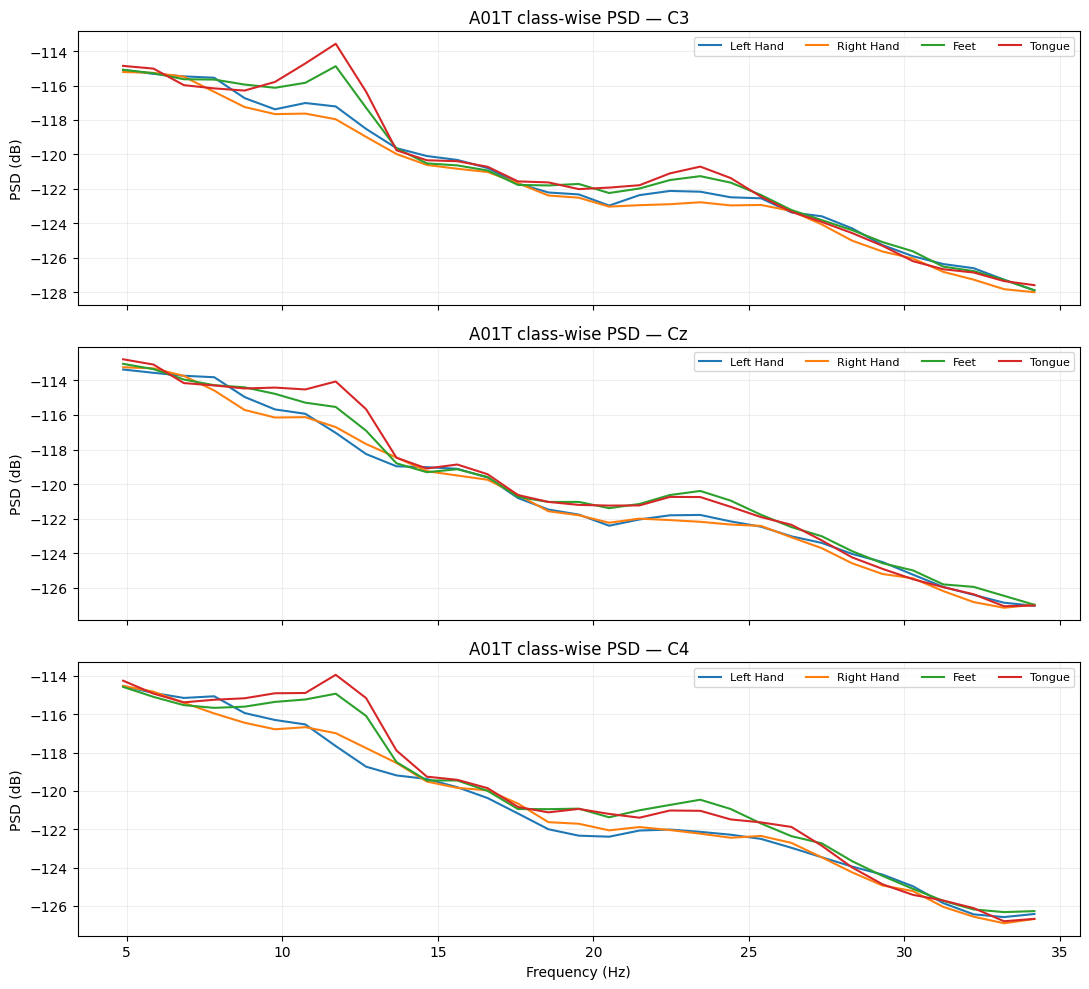

In [7]:
# ============================================================
# CELL 6 — FIXED CLASS-WISE PSD AUDIT
# ============================================================

MI_CH = {
    "C3": 7,
    "Cz": 9,
    "C4": 11,
}


def welch_class_psd(X, y, ch, fs=FS):

    rows = []

    for class_id, class_name in enumerate(CLASS_NAMES):

        # X = (trials, channels, time)
        # xc = (trials_in_class, time)
        xc = X[y == class_id, ch, :]

        if xc.shape[0] == 0:
            continue

        # Welch:
        # f -> (129,)
        # p -> (n_trials, 129)
        f, p = signal.welch(
            xc,
            fs=fs,
            nperseg=256,
            axis=-1
        )

        # Select frequencies
        mask = (f >= 4.0) & (f <= 35.0)

        # IMPORTANT:
        # Frequency is axis 1.
        p_selected = p[:, mask]

        # Average PSD across trials
        p_mean = p_selected.mean(axis=0)

        rows.append(
            (
                class_name,
                f[mask],
                p_mean
            )
        )

    return rows


def plot_class_psd(X, y, title):

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(11, 10),
        sharex=True
    )

    for ax, (channel_name, channel_index) in zip(
        axes,
        MI_CH.items()
    ):

        rows = welch_class_psd(
            X,
            y,
            channel_index
        )

        for class_name, f, p in rows:

            ax.plot(
                f,
                10 * np.log10(
                    p + 1e-15
                ),
                linewidth=1.5,
                label=class_name
            )

        ax.set_title(
            f"{title} — {channel_name}"
        )

        ax.set_ylabel(
            "PSD (dB)"
        )

        ax.grid(
            alpha=0.2
        )

        ax.legend(
            ncol=4,
            fontsize=8
        )

    axes[-1].set_xlabel(
        "Frequency (Hz)"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# RUN PSD AUDIT
# ============================================================

plot_class_psd(
    A01_XT,
    A01_yT,
    "A01T class-wise PSD"
)

In [8]:
# ============================================================
# CELL 7 — CONTROLLED WITHIN-SUBJECT A01T SPLIT
# ============================================================

def evaluate_lda(Xtr, ytr, Xva, yva, name):
    lda = LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")
    lda.fit(Xtr,ytr)
    pred=lda.predict(Xva)
    print(
        f"{name}: acc={accuracy_score(yva,pred)*100:.2f}% | "
        f"balanced={balanced_accuracy_score(yva,pred)*100:.2f}% | "
        f"kappa={cohen_kappa_score(yva,pred):.4f}"
    )
    return lda,pred

print("Within-subject check will use A01T only.")
idx_tr, idx_va = train_test_split(
    np.arange(len(A01_XT)),
    test_size=0.25,
    random_state=SEED,
    stratify=A01_yT
)
print("A01T split:", len(idx_tr), "train /", len(idx_va), "validation")


Within-subject check will use A01T only.
A01T split: 216 train / 72 validation


In [9]:
# ============================================================
# CELL 8 — FBCSP IMPLEMENTATION WITH TWO FEATURE DEFINITIONS
# ============================================================

class FBCSPDiagnostic:
    def __init__(self, m=4, regularization=0.0):
        self.m=m
        self.regularization=regularization
        self.W=[]
        self.meta=[]

    @staticmethod
    def cov_norm(x):
        c=x @ x.T
        tr=np.trace(c)
        return c/(tr+1e-12)

    def fit(self, Xfb, y):
        self.W=[]; self.meta=[]
        gi=0
        for b,(lo,hi) in enumerate(BANDS):
            Xb=Xfb[:,b]
            filters=[]
            for c in range(4):
                Rc=np.mean([self.cov_norm(x) for x in Xb[y==c]],axis=0)
                Rr=np.mean([self.cov_norm(x) for x in Xb[y!=c]],axis=0)
                if self.regularization>0:
                    I=np.eye(N_CHANNELS)
                    Rc=(1-self.regularization)*Rc+self.regularization*I/N_CHANNELS
                    Rr=(1-self.regularization)*Rr+self.regularization*I/N_CHANNELS
                vals, vecs=eigh(Rc+1e-10*np.eye(N_CHANNELS), Rr+1e-10*np.eye(N_CHANNELS))
                order=np.argsort(vals)[::-1]
                vals=vals[order]; vecs=vecs[:,order]
                W=vecs[:,:self.m]
                filters.append(W)
                for r in range(self.m):
                    self.meta.append({
                        "global_index":gi, "band":f"{lo}-{hi} Hz",
                        "band_index":b, "ovr_class":CLASS_NAMES[c],
                        "csp_rank":r+1, "eigenvalue":float(vals[r])
                    })
                    gi+=1
            self.W.append(np.hstack(filters))
        return self

    def _features_band(self, Xb, W, relative=True):
        Z=np.einsum("cf,nct->nft", W, Xb)
        v=np.var(Z,axis=-1)
        if relative:
            v=v/(np.sum(v,axis=1,keepdims=True)+1e-12)
        return np.log(v+1e-12)

    def transform(self, Xfb, relative=True):
        out=[]
        for b in range(len(BANDS)):
            out.append(self._features_band(Xfb[:,b], self.W[b], relative))
        return np.concatenate(out,axis=1)

def build_filter_bank(X, order=5):
    out=[]
    for lo,hi in BANDS:
        sos=signal.butter(order,[lo,hi],btype="bandpass",fs=FS,output="sos")
        out.append(signal.sosfiltfilt(sos,X,axis=-1).astype(np.float32))
    return np.stack(out,axis=1)


In [10]:
# ============================================================
# CELL 9 — TRAINING-ONLY NORMALIZATION + WITHIN-SUBJECT FBCSP
# ============================================================

def fit_norm(X):
    mu=X.mean(axis=(0,2),keepdims=True)
    sd=X.std(axis=(0,2),keepdims=True)+1e-6
    return mu.astype(np.float32),sd.astype(np.float32)

def norm(X,mu,sd):
    return ((X-mu)/sd).astype(np.float32)

# A01T-only fit for within-subject split
mu_t,sd_t=fit_norm(A01_XT[idx_tr])
Xtr_n=norm(A01_XT[idx_tr],mu_t,sd_t)
Xva_n=norm(A01_XT[idx_va],mu_t,sd_t)

print("within-subject z-score:")
print("max abs train mean:", float(np.max(np.abs(Xtr_n.mean(axis=(0,2))))))
print("max abs train std-1:", float(np.max(np.abs(Xtr_n.std(axis=(0,2))-1))))

Xtr_fb=build_filter_bank(Xtr_n)
Xva_fb=build_filter_bank(Xva_n)

fbcsp=FBCSPDiagnostic(m=4,regularization=0.0).fit(Xtr_fb,A01_yT[idx_tr])

Ftr_rel=fbcsp.transform(Xtr_fb,relative=True)
Fva_rel=fbcsp.transform(Xva_fb,relative=True)

Ftr_abs=fbcsp.transform(Xtr_fb,relative=False)
Fva_abs=fbcsp.transform(Xva_fb,relative=False)

print("candidate feature shape:", Ftr_rel.shape)

print("\nWITHIN-SUBJECT FBCSP+LDA — relative log-variance")
lda_rel,p_rel=evaluate_lda(Ftr_rel,A01_yT[idx_tr],Fva_rel,A01_yT[idx_va],"A01T split / relative")

print("\nWITHIN-SUBJECT FBCSP+LDA — absolute log-variance")
lda_abs,p_abs=evaluate_lda(Ftr_abs,A01_yT[idx_tr],Fva_abs,A01_yT[idx_va],"A01T split / absolute")


within-subject z-score:
max abs train mean: 1.7492858717105264e-08
max abs train std-1: 0.1296578049659729
candidate feature shape: (216, 160)

WITHIN-SUBJECT FBCSP+LDA — relative log-variance
A01T split / relative: acc=75.00% | balanced=75.00% | kappa=0.6667

WITHIN-SUBJECT FBCSP+LDA — absolute log-variance
A01T split / absolute: acc=76.39% | balanced=76.39% | kappa=0.6852


A01T -> A01E FBCSP+LDA
A01T → A01E: acc=75.69% | balanced=75.69% | kappa=0.6759


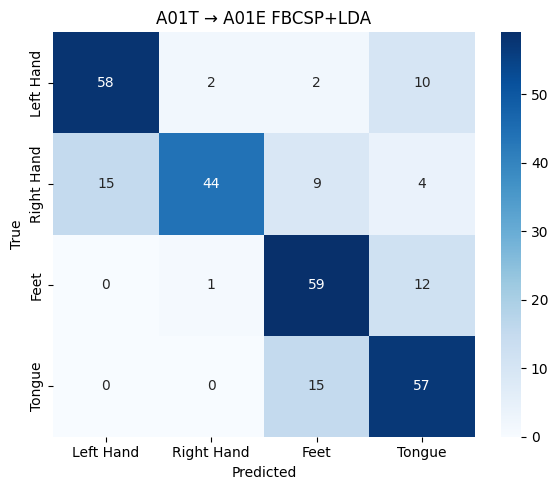

In [11]:
# ============================================================
# CELL 10 — CROSS-SESSION A01T → A01E CHECK
# ============================================================

# Fit normalization ONLY on A01T.
mu_cross, sd_cross = fit_norm(A01_XT)
XTn = norm(A01_XT,mu_cross,sd_cross)
XEn = norm(A01_XE,mu_cross,sd_cross)

XTfb=build_filter_bank(XTn)
XEfb=build_filter_bank(XEn)

cross_fbcsp=FBCSPDiagnostic(m=4,regularization=0.0).fit(XTfb,A01_yT)
F_T=cross_fbcsp.transform(XTfb,relative=True)
F_E=cross_fbcsp.transform(XEfb,relative=True)

print("A01T -> A01E FBCSP+LDA")
lda_cross,p_cross=evaluate_lda(
    F_T,A01_yT,F_E,A01_yE,"A01T → A01E"
)

cm=confusion_matrix(A01_yE,p_cross,labels=np.arange(4))
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",
            xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES)
plt.title("A01T → A01E FBCSP+LDA")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout(); plt.show()


LOADING ALL BCI IV-2a SUBJECTS
A01 labels: A01E.mat
A01: X=(576, 22, 1000) | class_counts=[144, 144, 144, 144] | time=1.2s
A02 labels: A02E.mat
A02: X=(576, 22, 1000) | class_counts=[144, 144, 144, 144] | time=1.1s
A03 labels: A03E.mat
A03: X=(576, 22, 1000) | class_counts=[144, 144, 144, 144] | time=1.0s
A04 labels: A04E.mat
A04: X=(576, 22, 1000) | class_counts=[144, 144, 144, 144] | time=1.0s
A05 labels: A05E.mat
A05: X=(576, 22, 1000) | class_counts=[144, 144, 144, 144] | time=1.1s
A06 labels: A06E.mat
A06: X=(576, 22, 1000) | class_counts=[144, 144, 144, 144] | time=1.1s
A07 labels: A07E.mat
A07: X=(576, 22, 1000) | class_counts=[144, 144, 144, 144] | time=1.2s
A08 labels: A08E.mat
A08: X=(576, 22, 1000) | class_counts=[144, 144, 144, 144] | time=1.1s
A09 labels: A09E.mat
A09: X=(576, 22, 1000) | class_counts=[144, 144, 144, 144] | time=1.0s

STRICT LOSO CHECK
Train subjects : ['A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09']
Test subject   : A01
Train shape    : (4608, 22,

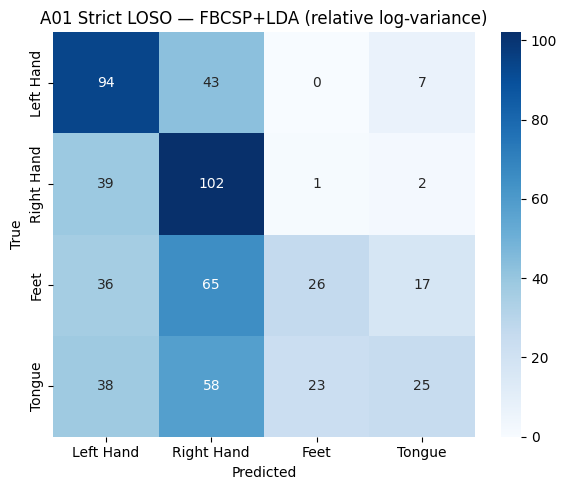


------------------------------------------------------------------------
A01 STRICT LOSO — FBCSP + LDA
absolute log-variance
------------------------------------------------------------------------
A02-A09 → A01: acc=40.97% | balanced=40.97% | kappa=0.2130


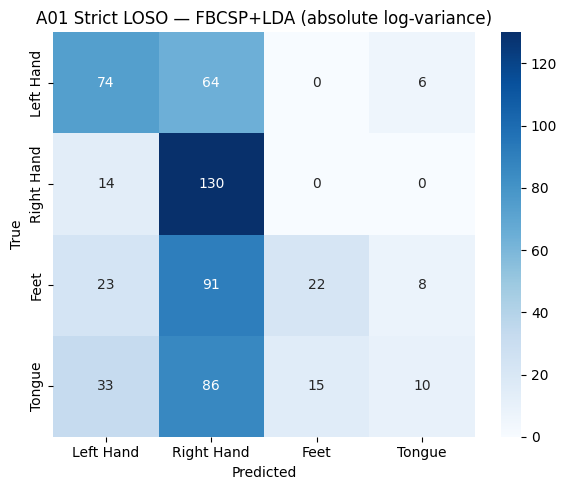


Cell 11 complete.


In [12]:
# ============================================================
# CELL 11 — STRICT LOSO A01 FBCSP DIAGNOSTIC (SELF-CONTAINED)
# ============================================================
# This replaces the previous Cell 11.
#
# The previous version expected a variable called `subjects`
# from another notebook. That variable does not exist in this
# standalone notebook, so the cell raised:
#
# RuntimeError: Run the original real-data loading notebook...
#
# This version loads A01-A09 directly from the GDF files using
# the utilities already defined in Cells 1-10.

def load_subject_2a(subject_id):
    """
    Load one BCI IV-2a subject:
      - T session: 288 trials, labels from GDF events 769-772
      - E session: 288 trials, labels from true_labels/*
    Returns:
      X: (576, 22, 1000)
      y: (576,)
      meta: trial/session metadata
    """
    # -------------------------
    # Training session
    # -------------------------
    t_path = DATA_ROOT / f"{subject_id}T.gdf"
    if not t_path.exists():
        raise FileNotFoundError(f"Missing {t_path}")

    _, eeg_T, meta_T = get_trial_metadata(t_path, "T")
    X_T = epoch_from_continuous(eeg_T, meta_T)

    if len(meta_T) != 288 or X_T.shape != (288, N_CHANNELS, N_TIME):
        raise ValueError(
            f"{subject_id}T unexpected shape/meta: "
            f"meta={len(meta_T)}, X={X_T.shape}"
        )

    y_T = np.array(
        [EVENT_TO_CLASS[int(c)] for c in meta_T["event_code"]],
        dtype=np.int64
    )

    # -------------------------
    # Evaluation session
    # -------------------------
    e_path = DATA_ROOT / f"{subject_id}E.gdf"
    if not e_path.exists():
        raise FileNotFoundError(f"Missing {e_path}")

    _, eeg_E, meta_E = get_trial_metadata(e_path, "E")
    X_E = epoch_from_continuous(eeg_E, meta_E)

    if len(meta_E) != 288 or X_E.shape != (288, N_CHANNELS, N_TIME):
        raise ValueError(
            f"{subject_id}E unexpected shape/meta: "
            f"meta={len(meta_E)}, X={X_E.shape}"
        )

    y_E = load_true_labels(subject_id, 288)

    # -------------------------
    # IMPORTANT: verify E order
    # -------------------------
    if len(y_E) != len(X_E):
        raise ValueError(
            f"{subject_id}E label count mismatch: "
            f"{len(y_E)} labels vs {len(X_E)} epochs"
        )

    X = np.concatenate([X_T, X_E], axis=0)
    y = np.concatenate([y_T, y_E], axis=0)

    meta = pd.concat([
        meta_T.assign(session="T"),
        meta_E.assign(session="E")
    ], ignore_index=True)

    return X.astype(np.float32), y.astype(np.int64), meta


def load_all_subjects_2a(subject_ids=None):
    if subject_ids is None:
        subject_ids = [f"A{i:02d}" for i in range(1, 10)]

    datasets = {}

    print("=" * 72)
    print("LOADING ALL BCI IV-2a SUBJECTS")
    print("=" * 72)

    for sid in subject_ids:
        t0 = time.time()

        X, y, meta = load_subject_2a(sid)

        datasets[sid] = {
            "X": X,
            "y": y,
            "meta": meta
        }

        counts = np.bincount(y, minlength=4)

        print(
            f"{sid}: X={X.shape} | "
            f"class_counts={counts.tolist()} | "
            f"time={time.time()-t0:.1f}s"
        )

        # Every subject should have 144 trials/class total.
        if not np.array_equal(counts, np.array([144, 144, 144, 144])):
            raise ValueError(
                f"{sid}: unexpected class counts {counts.tolist()}"
            )

    print("=" * 72)
    return datasets


# ------------------------------------------------------------
# LOAD THE DATASET DIRECTLY FROM THIS NOTEBOOK
# ------------------------------------------------------------

ALL_SUBJECTS = load_all_subjects_2a()

# ------------------------------------------------------------
# STRICT LOSO A01
# ------------------------------------------------------------

TEST_SUBJECT = "A01"
TRAIN_SUBJECTS = [
    sid for sid in ALL_SUBJECTS.keys()
    if sid != TEST_SUBJECT
]

X_loso = np.concatenate(
    [ALL_SUBJECTS[sid]["X"] for sid in TRAIN_SUBJECTS],
    axis=0
)

y_loso = np.concatenate(
    [ALL_SUBJECTS[sid]["y"] for sid in TRAIN_SUBJECTS],
    axis=0
)

X_test_loso = ALL_SUBJECTS[TEST_SUBJECT]["X"]
y_test_loso = ALL_SUBJECTS[TEST_SUBJECT]["y"]

print("\nSTRICT LOSO CHECK")
print("Train subjects :", TRAIN_SUBJECTS)
print("Test subject   :", TEST_SUBJECT)
print("Train shape    :", X_loso.shape)
print("Test shape     :", X_test_loso.shape)
print("Train classes  :", np.bincount(y_loso, minlength=4))
print("Test classes   :", np.bincount(y_test_loso, minlength=4))

# ------------------------------------------------------------
# TRAINING-ONLY NORMALIZATION
# ------------------------------------------------------------

mu_l, sd_l = fit_norm(X_loso)

Xln = norm(X_loso, mu_l, sd_l)
XTn = norm(X_test_loso, mu_l, sd_l)

print("\nNORMALIZATION CHECK")
print("max |train mean|:", float(np.max(np.abs(Xln.mean(axis=(0,2))))))
print(
    "max |train std-1|:",
    float(np.max(np.abs(Xln.std(axis=(0,2)) - 1)))
)

# ------------------------------------------------------------
# FILTER BANK
# ------------------------------------------------------------

print("\nBUILDING 10-BAND FILTER BANK...")
Xlfb = build_filter_bank(Xln)
XTfb = build_filter_bank(XTn)

print("filter-bank train:", Xlfb.shape)
print("filter-bank test :", XTfb.shape)

# ------------------------------------------------------------
# FBCSP FIT ONLY ON TRAINING SUBJECTS
# ------------------------------------------------------------

print("\nFITTING FBCSP ON A02-A09 ONLY...")

loso_fbcsp = FBCSPDiagnostic(
    m=4,
    regularization=0.0
).fit(Xlfb, y_loso)

print("FBCSP candidate dimensions:", len(loso_fbcsp.meta))

# ------------------------------------------------------------
# COMPARE TWO CSP FEATURE DEFINITIONS
# ------------------------------------------------------------

for relative in [True, False]:

    label = "relative log-variance" if relative else "absolute log-variance"

    F_l = loso_fbcsp.transform(
        Xlfb,
        relative=relative
    )

    F_t = loso_fbcsp.transform(
        XTfb,
        relative=relative
    )

    print("\n" + "-" * 72)
    print("A01 STRICT LOSO — FBCSP + LDA")
    print(label)
    print("-" * 72)

    lda_loso, pred_loso = evaluate_lda(
        F_l,
        y_loso,
        F_t,
        y_test_loso,
        "A02-A09 → A01"
    )

    cm = confusion_matrix(
        y_test_loso,
        pred_loso,
        labels=np.arange(4)
    )

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )
    plt.title(f"A01 Strict LOSO — FBCSP+LDA ({label})")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

print("\nCell 11 complete.")


### Note about the previous error

The earlier Cell 11 depended on a variable named `subjects` that was created in a different notebook. This notebook is now self-contained: it loads A01–A09 directly from the `.gdf` files and the `true_labels` folder before constructing the strict A01 LOSO fold.

The strict LOSO split remains:
- Training: A02–A09 = 4,608 trials
- Test: A01 = 576 trials


In [13]:
# ============================================================
# CELL 12 — DIAGNOSTIC DECISION GATE
# ============================================================

results = {
    "within_subject_A01T_relative": accuracy_score(A01_yT[idx_va], p_rel),
    "within_subject_A01T_absolute": accuracy_score(A01_yT[idx_va], p_abs),
    "cross_session_A01T_to_A01E": accuracy_score(A01_yE, p_cross),
}

print(pd.Series(results).mul(100).round(2).to_string())

print("\nINTERPRETATION GATE")
print("1. Within-subject >= ~50% and cross-session >= ~40%:")
print("   EEG/event extraction is likely usable; LOSO subject shift is the main difficulty.")
print("2. Within-subject ~25-35%:")
print("   Strong evidence of a preprocessing/FBCSP/event-alignment problem.")
print("3. Within-subject good but cross-session poor:")
print("   Session shift / normalization / label-order issue needs attention.")
print("4. Relative-vs-absolute variance changes performance substantially:")
print("   FBCSP feature definition is a meaningful source of the gap.")
print("\nDo NOT enable FBGAN yet.")


within_subject_A01T_relative    75.00
within_subject_A01T_absolute    76.39
cross_session_A01T_to_A01E      75.69

INTERPRETATION GATE
1. Within-subject >= ~50% and cross-session >= ~40%:
   EEG/event extraction is likely usable; LOSO subject shift is the main difficulty.
2. Within-subject ~25-35%:
   Strong evidence of a preprocessing/FBCSP/event-alignment problem.
3. Within-subject good but cross-session poor:
   Session shift / normalization / label-order issue needs attention.
4. Relative-vs-absolute variance changes performance substantially:
   FBCSP feature definition is a meaningful source of the gap.

Do NOT enable FBGAN yet.


## Expected next step

After these diagnostics, use the result to decide:

- **Data-alignment problem** → fix GDF/event/label extraction.
- **Within-subject good, LOSO poor** → keep preprocessing and focus on subject-invariant CRNN/domain adaptation.
- **Relative vs absolute FBCSP differs strongly** → use the paper-consistent feature definition consistently.
- **All classical checks are good but CRNN remains low** → inspect the exact CRNN-DF implementation and optimization.

The paper's reported values are still the final references:
- CRNN-DF: **63.52 ± 10.70%**
- CRNN-DF + 3,000 FBGAN samples: **72.82 ± 10.44%**

These numbers should be compared only after the evaluation protocol is fixed and the A01 test subject remains untouched during model selection.


# STAGE 1 — Paper-faithful CRNN baseline

The preprocessing/FBCSP diagnostics established:

- A01T within-subject FBCSP+LDA ≈ 75%
- A01T → A01E FBCSP+LDA ≈ 75.7%
- A02–A09 → A01 FBCSP+LDA ≈ 42.9%

This stage isolates the deep classifier.

**Center/discriminative loss is disabled (`lambda = 0`)** so that the paper-faithful CRNN baseline is established before adding CRNN-DF.

The paper describes:
- spatial convolution with kernel `C × 45`;
- max pooling `1 × 75`, stride 10;
- two LSTM layers with hidden size 64;
- dropout 0.5;
- learning rate `1e-4`, batch size 32.

The classifier input remains normalized `22 × 1000` EEG.


In [14]:
# ============================================================
# CELL — PAPER-FAITHFUL CRNN BASELINE
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

class PaperCRNN(nn.Module):
    """Stage-1 CRNN baseline.

    Input:
        (B, 22, 1000)

    Output:
        logits: (B, 4)
        features: (B, 64) when return_features=True
    """

    def __init__(
        self,
        n_channels=22,
        n_classes=4,
        hidden_size=64,
        dropout=0.5
    ):
        super().__init__()

        self.conv = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=(n_channels, 45),
            stride=(1, 1),
            padding=(0, 0),
            bias=False
        )

        self.bn = nn.BatchNorm2d(32)
        self.conv_dropout = nn.Dropout(dropout)

        self.pool = nn.MaxPool2d(
            kernel_size=(1, 75),
            stride=(1, 10)
        )

        self.lstm = nn.LSTM(
            input_size=32,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            dropout=dropout
        )

        self.feature_dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(
            hidden_size,
            n_classes
        )

    def forward(self, x, return_features=False):
        # x: (B, 22, 1000)
        x = x.unsqueeze(1)            # (B, 1, 22, 1000)
        x = self.conv(x)              # (B, 32, 1, 956)
        x = self.bn(x)
        x = F.relu(x)
        x = self.conv_dropout(x)

        x = self.pool(x)              # (B, 32, 1, 89)
        x = x.squeeze(2)              # (B, 32, 89)
        x = x.transpose(1, 2)         # (B, 89, 32)

        lstm_out, _ = self.lstm(x)    # (B, 89, 64)

        features = lstm_out[:, -1, :] # (B, 64)
        features = self.feature_dropout(features)

        logits = self.fc(features)

        if return_features:
            return logits, features

        return logits


In [15]:
# ============================================================
# CELL — PAPER CRNN TRAINING
# ============================================================

def train_paper_crnn(
    X_train,
    y_train,
    X_test,
    y_test,
    epochs=150,
    batch_size=32,
    lr=1e-4,
    seed=42
):
    """Train/evaluate the paper-style CRNN on a strict LOSO fold."""

    reset_seed(seed)

    if torch.backends.mps.is_available():
        device = torch.device("mps")
    else:
        device = torch.device("cpu")

    print("Device:", device)

    model = PaperCRNN(
        n_channels=22,
        n_classes=4,
        hidden_size=64,
        dropout=0.5
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    criterion = nn.CrossEntropyLoss()

    X_train_t = torch.tensor(
        X_train,
        dtype=torch.float32
    )

    y_train_t = torch.tensor(
        y_train,
        dtype=torch.long
    )

    X_test_t = torch.tensor(
        X_test,
        dtype=torch.float32
    )

    train_dataset = torch.utils.data.TensorDataset(
        X_train_t,
        y_train_t
    )

    generator = torch.Generator()
    generator.manual_seed(seed)

    loader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=generator,
        drop_last=False
    )

    history = []

    for epoch in range(1, epochs + 1):

        model.train()

        running_loss = 0.0
        running_correct = 0
        running_total = 0

        for xb, yb in loader:

            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad(set_to_none=True)

            logits = model(xb)

            loss = criterion(logits, yb)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=5.0
            )

            optimizer.step()

            running_loss += loss.item() * len(yb)

            running_correct += (
                (logits.argmax(dim=1) == yb)
                .sum()
                .item()
            )

            running_total += len(yb)

        train_loss = running_loss / running_total
        train_acc = running_correct / running_total

        model.eval()
        pred_parts = []

        with torch.no_grad():
            for start in range(0, len(X_test_t), batch_size):
                xb = X_test_t[start:start + batch_size].to(device)

                logits = model(xb)

                pred_parts.append(
                    logits.argmax(dim=1).cpu().numpy()
                )

        y_pred = np.concatenate(pred_parts)

        test_acc = accuracy_score(
            y_test,
            y_pred
        )

        history.append({
            "epoch": epoch,
            "loss": float(train_loss),
            "train_accuracy": float(train_acc),
            "test_accuracy": float(test_acc)
        })

        if epoch == 1 or epoch % 10 == 0 or epoch == epochs:
            print(
                f"Epoch {epoch:03d} | "
                f"loss={train_loss:.4f} | "
                f"train={train_acc * 100:.2f}% | "
                f"test={test_acc * 100:.2f}%"
            )

    balanced_acc = balanced_accuracy_score(
        y_test,
        y_pred
    )

    kappa = cohen_kappa_score(
        y_test,
        y_pred
    )

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=np.arange(4)
    )

    print("\n" + "=" * 72)
    print("A01 PAPER CRNN BASELINE")
    print("=" * 72)
    print(f"Accuracy      : {accuracy_score(y_test, y_pred) * 100:.2f}%")
    print(f"Balanced Acc  : {balanced_acc * 100:.2f}%")
    print(f"Kappa         : {kappa:.4f}")
    print("=" * 72)

    plt.figure(figsize=(7, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )

    plt.title("A01 — Paper CRNN Baseline")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    hist_df = pd.DataFrame(history)

    plt.figure(figsize=(10, 5))
    plt.plot(
        hist_df["epoch"],
        hist_df["train_accuracy"] * 100,
        label="Train accuracy"
    )
    plt.plot(
        hist_df["epoch"],
        hist_df["test_accuracy"] * 100,
        label="A01 test accuracy"
    )
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title("A01 CRNN Training / Held-out Accuracy")
    plt.grid(alpha=0.2)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {
        "model": model,
        "history": hist_df,
        "predictions": y_pred,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_acc,
        "kappa": kappa,
        "confusion_matrix": cm,
        "device": device
    }


Device: mps
Epoch 001 | loss=1.3891 | train=26.00% | test=25.69%
Epoch 010 | loss=1.2916 | train=37.35% | test=34.55%
Epoch 020 | loss=1.1871 | train=46.09% | test=32.29%
Epoch 030 | loss=1.0937 | train=52.32% | test=31.94%
Epoch 040 | loss=1.0250 | train=56.75% | test=33.33%
Epoch 050 | loss=0.9781 | train=59.11% | test=35.07%
Epoch 060 | loss=0.9204 | train=61.87% | test=34.20%
Epoch 070 | loss=0.8731 | train=64.50% | test=36.63%
Epoch 080 | loss=0.8448 | train=65.80% | test=38.02%
Epoch 090 | loss=0.8043 | train=68.47% | test=39.41%
Epoch 100 | loss=0.7738 | train=69.21% | test=39.58%
Epoch 110 | loss=0.7241 | train=71.83% | test=37.50%
Epoch 120 | loss=0.6882 | train=73.85% | test=44.79%
Epoch 130 | loss=0.6881 | train=73.70% | test=45.83%
Epoch 140 | loss=0.6312 | train=76.09% | test=47.74%
Epoch 150 | loss=0.6240 | train=76.69% | test=43.06%

A01 PAPER CRNN BASELINE
Accuracy      : 43.06%
Balanced Acc  : 43.06%
Kappa         : 0.2407


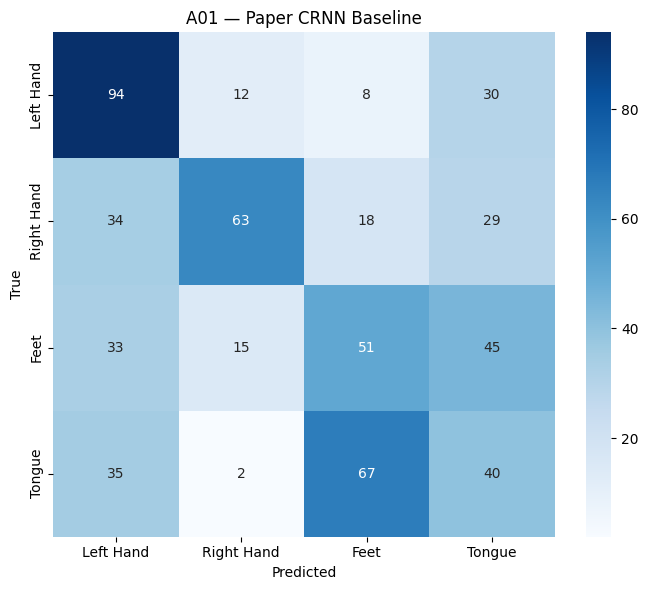

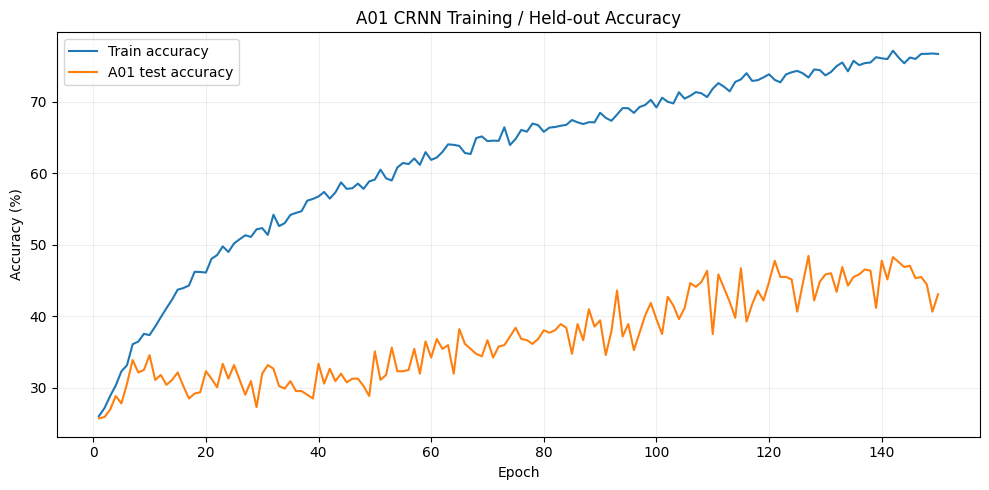


Stage-1 CRNN-only A01 = 43.06%


In [16]:
# ============================================================
# CELL — RUN STAGE-1 CRNN ON A01 STRICT LOSO
# ============================================================

assert Xln.shape == (4608, 22, 1000)
assert XTn.shape == (576, 22, 1000)

paper_crnn_result = train_paper_crnn(
    X_train=Xln,
    y_train=y_loso,
    X_test=XTn,
    y_test=y_test_loso,
    epochs=150,
    batch_size=32,
    lr=1e-4,
    seed=42
)

print(
    f"\nStage-1 CRNN-only A01 = "
    f"{paper_crnn_result['accuracy'] * 100:.2f}%"
)


# STAGE 2 — CRNN-DF on Real BCI IV-2a

This notebook extends the validated real-data pipeline with the discriminative-feature stage.

Current validated baselines:
- A01T within-subject FBCSP+LDA ≈ 75%
- A01T → A01E FBCSP+LDA ≈ 75.7%
- A02–A09 → A01 FBCSP+LDA ≈ 42.9%
- A02–A09 → A01 mean-temporal CRNN ≈ 44.3%

This stage adds:
- 64-D mean-temporal CRNN embedding
- class-center initialization
- central-distance loss
- centroid shift
- λ = 0.1
- α = 0.02
- center update every 15 epochs
- batch size 32
- learning rate 1e-4
- 150 epochs

The held-out A01 subject is evaluated only after training. No FBGAN is enabled in this stage.


In [17]:
# ============================================================
# CELL — CRNN-DF MODEL
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

class CRNNDF(nn.Module):
    """
    CRNN-DF using the validated mean-temporal 64-D embedding.

    Input:
        (B, 22, 1000)

    Returns:
        logits:   (B, 4)
        features: (B, 64) when return_features=True
    """

    def __init__(
        self,
        n_channels=22,
        n_classes=4,
        hidden_size=64,
        dropout=0.5
    ):
        super().__init__()

        self.conv = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=(n_channels, 45),
            stride=(1, 1),
            padding=(0, 0),
            bias=False
        )

        self.bn = nn.BatchNorm2d(32)

        self.conv_dropout = nn.Dropout(dropout)

        self.pool = nn.MaxPool2d(
            kernel_size=(1, 75),
            stride=(1, 10)
        )

        self.lstm = nn.LSTM(
            input_size=32,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            dropout=dropout
        )

        self.feature_dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(
            hidden_size,
            n_classes
        )

    def extract_features(self, x):

        # x: (B, 22, 1000)
        x = x.unsqueeze(1)

        # (B, 1, 22, 1000)
        x = self.conv(x)

        # (B, 32, 1, 956)
        x = self.bn(x)
        x = F.relu(x)
        x = self.conv_dropout(x)

        # (B, 32, 1, 89)
        x = self.pool(x)

        # (B, 32, 89)
        x = x.squeeze(2)

        # (B, 89, 32)
        x = x.transpose(1, 2)

        # (B, 89, 64)
        lstm_out, _ = self.lstm(x)

        # Validated Stage-1 temporal aggregation
        features = lstm_out.mean(dim=1)

        # (B, 64)
        features = self.feature_dropout(features)

        return features

    def forward(self, x, return_features=False):

        features = self.extract_features(x)
        logits = self.fc(features)

        if return_features:
            return logits, features

        return logits


In [18]:
# ============================================================
# CELL — CLASS CENTER INITIALIZATION
# ============================================================

def initialize_class_centers(
    model,
    X_train,
    y_train,
    device,
    batch_size=64
):
    """
    Initialize one 64-D center per class using the initial
    feature representation of the training set.
    """

    model.eval()

    dataset = torch.utils.data.TensorDataset(
        torch.tensor(
            X_train,
            dtype=torch.float32
        ),
        torch.tensor(
            y_train,
            dtype=torch.long
        )
    )

    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False
    )

    feature_parts = []
    label_parts = []

    with torch.no_grad():

        for xb, yb in loader:

            xb = xb.to(device)

            feats = model.extract_features(xb)

            feature_parts.append(
                feats.cpu()
            )

            label_parts.append(
                yb.cpu()
            )

    features = torch.cat(
        feature_parts,
        dim=0
    )

    labels = torch.cat(
        label_parts,
        dim=0
    )

    centers = []

    for class_id in range(4):

        class_features = features[
            labels == class_id
        ]

        if len(class_features) == 0:
            raise ValueError(
                f"No samples found for class {class_id}"
            )

        centers.append(
            class_features.mean(dim=0)
        )

    return torch.stack(
        centers,
        dim=0
    ).to(device)


In [19]:
# ============================================================
# CELL — CENTER LOSS + CENTROID SHIFT
# ============================================================

def central_distance_loss(
    features,
    labels,
    centers
):
    """
    Mean Euclidean distance from each feature vector to its
    corresponding class center.
    """

    target_centers = centers[labels]

    return torch.norm(
        features - target_centers,
        p=2,
        dim=1
    ).mean()


@torch.no_grad()
def shift_class_centers(
    centers,
    alpha=0.02
):
    """
    Move each class center slightly away from the global center.

    This is the paper-inspired centroid-shift step.
    """

    global_center = centers.mean(
        dim=0
    )

    shifted = centers.clone()

    for class_id in range(
        centers.shape[0]
    ):

        direction = (
            centers[class_id]
            - global_center
        )

        norm = torch.norm(
            direction
        )

        if norm > 1e-12:
            direction = direction / norm

        shifted[class_id] = (
            centers[class_id]
            + alpha * direction
        )

    return shifted


In [20]:
# ============================================================
# CELL — CRNN-DF TRAINING
# ============================================================

def train_crnndf(
    X_train,
    y_train,
    X_test,
    y_test,
    epochs=150,
    batch_size=32,
    lr=1e-4,
    lambda_center=0.1,
    alpha=0.02,
    center_update_every=15,
    seed=42
):

    reset_seed(seed)

    if torch.backends.mps.is_available():
        device = torch.device("mps")
    else:
        device = torch.device("cpu")

    print("Device:", device)

    # --------------------------------------------------------
    # MODEL
    # --------------------------------------------------------

    model = CRNNDF(
        n_channels=22,
        n_classes=4,
        hidden_size=64,
        dropout=0.5
    ).to(device)

    # --------------------------------------------------------
    # OPTIMIZER
    # --------------------------------------------------------

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    criterion = nn.CrossEntropyLoss()

    # --------------------------------------------------------
    # TRAIN TENSORS
    # --------------------------------------------------------

    X_train_t = torch.tensor(
        X_train,
        dtype=torch.float32
    )

    y_train_t = torch.tensor(
        y_train,
        dtype=torch.long
    )

    dataset = torch.utils.data.TensorDataset(
        X_train_t,
        y_train_t
    )

    generator = torch.Generator()
    generator.manual_seed(seed)

    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=generator,
        drop_last=False
    )

    # --------------------------------------------------------
    # INITIAL CLASS CENTERS
    # --------------------------------------------------------

    print("\nInitializing class centers...")

    centers = initialize_class_centers(
        model=model,
        X_train=X_train,
        y_train=y_train,
        device=device,
        batch_size=64
    )

    print(
        "Initial centers:",
        tuple(centers.shape)
    )

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    history = []

    for epoch in range(
        1,
        epochs + 1
    ):

        model.train()

        sum_loss = 0.0
        sum_ce = 0.0
        sum_cen = 0.0

        correct = 0
        total = 0

        for xb, yb in loader:

            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad(
                set_to_none=True
            )

            logits, features = model(
                xb,
                return_features=True
            )

            ce_loss = criterion(
                logits,
                yb
            )

            cen_loss = central_distance_loss(
                features,
                yb,
                centers
            )

            loss = (
                ce_loss
                + lambda_center * cen_loss
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=5.0
            )

            optimizer.step()

            batch_n = len(yb)

            sum_loss += loss.item() * batch_n
            sum_ce += ce_loss.item() * batch_n
            sum_cen += cen_loss.item() * batch_n

            correct += (
                (logits.argmax(dim=1) == yb)
                .sum()
                .item()
            )

            total += batch_n

        epoch_loss = sum_loss / total
        epoch_ce = sum_ce / total
        epoch_cen = sum_cen / total
        train_acc = correct / total

        # ----------------------------------------------------
        # CENTROID SHIFT
        # ----------------------------------------------------

        if epoch % center_update_every == 0:

            centers = shift_class_centers(
                centers,
                alpha=alpha
            )

        history.append({
            "epoch": epoch,
            "loss": epoch_loss,
            "ce": epoch_ce,
            "center_loss": epoch_cen,
            "train_accuracy": train_acc
        })

        if (
            epoch == 1
            or epoch % 10 == 0
            or epoch == epochs
        ):

            print(
                f"Epoch {epoch:03d} | "
                f"loss={epoch_loss:.4f} | "
                f"CE={epoch_ce:.4f} | "
                f"CEN={epoch_cen:.4f} | "
                f"train={train_acc*100:.2f}%"
            )

    # --------------------------------------------------------
    # FINAL A01 EVALUATION
    # --------------------------------------------------------

    model.eval()

    X_test_t = torch.tensor(
        X_test,
        dtype=torch.float32
    )

    prediction_parts = []

    with torch.no_grad():

        for start in range(
            0,
            len(X_test_t),
            batch_size
        ):

            xb = X_test_t[
                start:start + batch_size
            ].to(device)

            logits = model(xb)

            prediction_parts.append(
                logits.argmax(
                    dim=1
                ).cpu().numpy()
            )

    y_pred = np.concatenate(
        prediction_parts
    )

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    balanced_acc = balanced_accuracy_score(
        y_test,
        y_pred
    )

    kappa = cohen_kappa_score(
        y_test,
        y_pred
    )

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=np.arange(4)
    )

    # --------------------------------------------------------
    # OUTPUT
    # --------------------------------------------------------

    print("\n" + "=" * 72)
    print("A01 PAPER-STYLE CRNN-DF")
    print("=" * 72)

    print(
        f"Accuracy      : {accuracy*100:.2f}%"
    )

    print(
        f"Balanced Acc  : {balanced_acc*100:.2f}%"
    )

    print(
        f"Kappa         : {kappa:.4f}"
    )

    print("=" * 72)

    plt.figure(
        figsize=(7, 6)
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )

    plt.title(
        "A01 — CRNN-DF"
    )

    plt.xlabel("Predicted")
    plt.ylabel("True")

    plt.tight_layout()
    plt.show()

    history_df = pd.DataFrame(history)

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(10, 12)
    )

    axes[0].plot(
        history_df["epoch"],
        history_df["loss"]
    )
    axes[0].set_title("Total Loss")
    axes[0].set_ylabel("Loss")

    axes[1].plot(
        history_df["epoch"],
        history_df["ce"]
    )
    axes[1].set_title("Cross Entropy")
    axes[1].set_ylabel("CE")

    axes[2].plot(
        history_df["epoch"],
        history_df["center_loss"]
    )
    axes[2].set_title("Center Distance Loss")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Center loss")

    plt.tight_layout()
    plt.show()

    return {
        "model": model,
        "centers": centers,
        "history": history_df,
        "predictions": y_pred,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_acc,
        "kappa": kappa,
        "confusion_matrix": cm,
        "device": device
    }


Device: mps

Initializing class centers...
Initial centers: (4, 64)
Epoch 001 | loss=1.4388 | CE=1.3878 | CEN=0.5101 | train=26.28%
Epoch 010 | loss=1.2831 | CE=1.1621 | CEN=1.2101 | train=49.20%
Epoch 020 | loss=1.2044 | CE=1.0723 | CEN=1.3213 | train=54.12%
Epoch 030 | loss=1.0902 | CE=0.9475 | CEN=1.4272 | train=60.26%
Epoch 040 | loss=1.0231 | CE=0.8784 | CEN=1.4467 | train=64.63%
Epoch 050 | loss=0.9785 | CE=0.8345 | CEN=1.4407 | train=66.78%
Epoch 060 | loss=0.9088 | CE=0.7653 | CEN=1.4350 | train=70.14%
Epoch 070 | loss=0.8523 | CE=0.7101 | CEN=1.4219 | train=72.85%
Epoch 080 | loss=0.8225 | CE=0.6851 | CEN=1.3742 | train=74.09%
Epoch 090 | loss=0.7727 | CE=0.6348 | CEN=1.3788 | train=76.32%
Epoch 100 | loss=0.7348 | CE=0.5986 | CEN=1.3617 | train=77.76%
Epoch 110 | loss=0.6850 | CE=0.5499 | CEN=1.3504 | train=79.75%
Epoch 120 | loss=0.6543 | CE=0.5202 | CEN=1.3407 | train=80.90%
Epoch 130 | loss=0.6190 | CE=0.4872 | CEN=1.3183 | train=81.99%
Epoch 140 | loss=0.6167 | CE=0.4867 

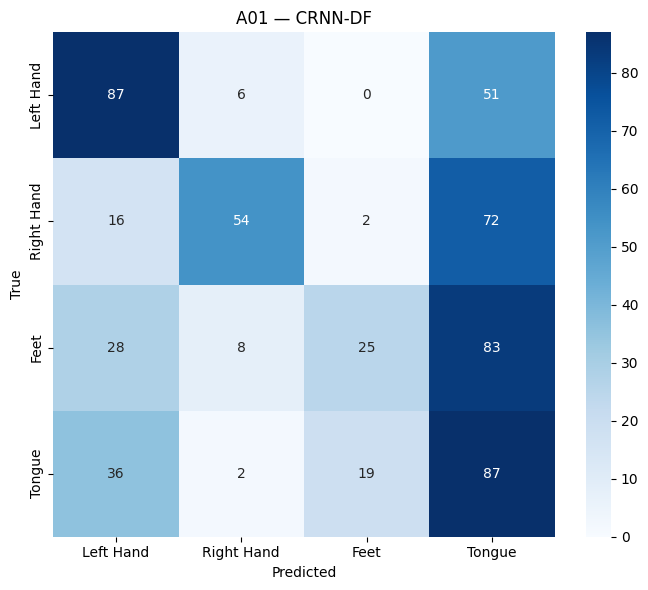

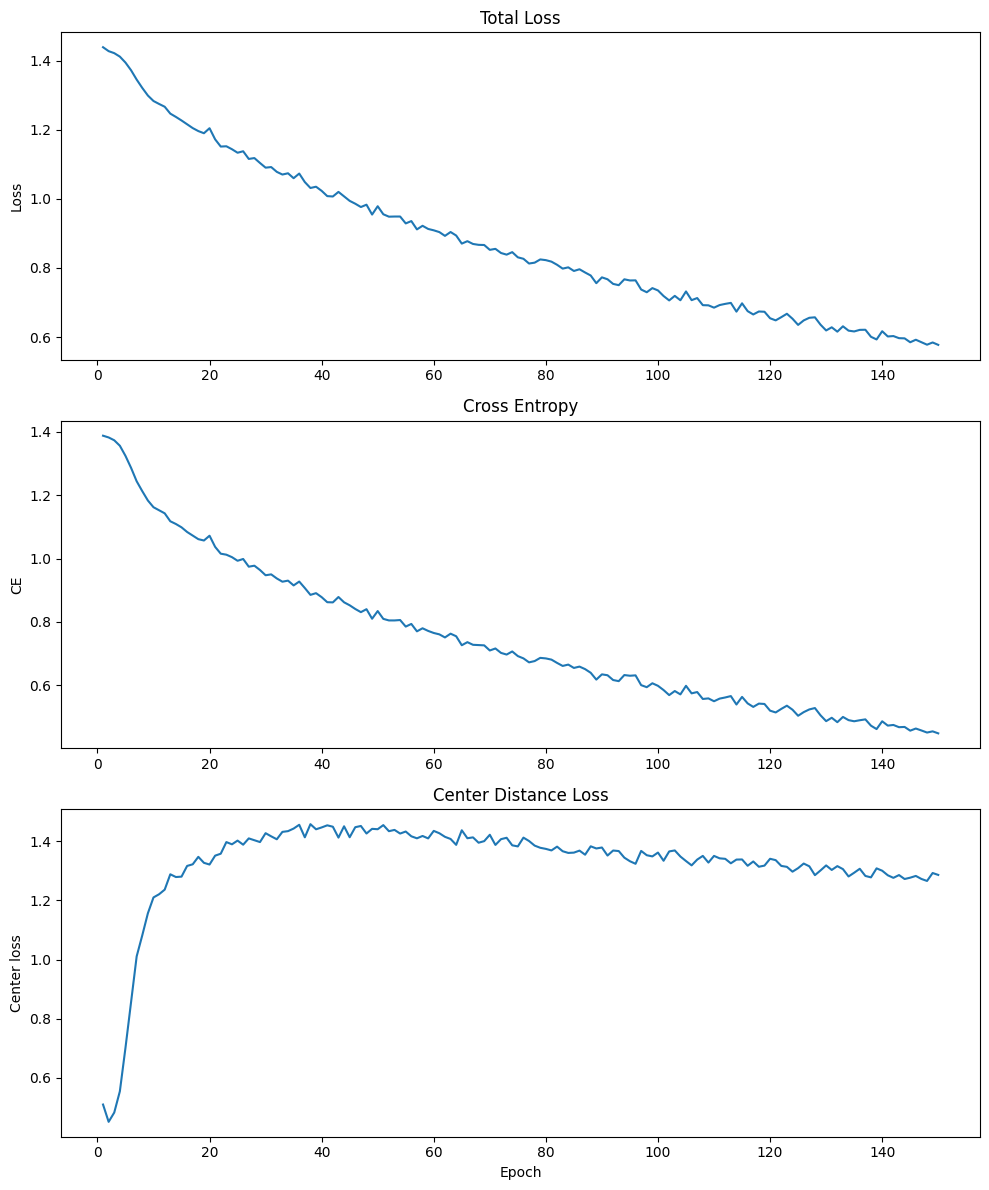


A01 CRNN-DF = 43.92%


In [21]:
# ============================================================
# CELL — RUN A01 CRNN-DF
# ============================================================

assert Xln.shape == (4608, 22, 1000)
assert XTn.shape == (576, 22, 1000)

crnndf_result = train_crnndf(
    X_train=Xln,
    y_train=y_loso,
    X_test=XTn,
    y_test=y_test_loso,

    epochs=150,
    batch_size=32,
    lr=1e-4,

    lambda_center=0.1,
    alpha=0.02,
    center_update_every=15,

    seed=42
)

print(
    f"\nA01 CRNN-DF = "
    f"{crnndf_result['accuracy']*100:.2f}%"
)


In [22]:
# ============================================================
# CELL — A01 BASELINE COMPARISON
# ============================================================

comparison_df = pd.DataFrame({
    "Model": [
        "FBCSP + LDA",
        "CRNN mean-temporal",
        "CRNN-DF"
    ],
    "A01 Accuracy (%)": [
        42.88,
        44.27,
        crnndf_result["accuracy"] * 100
    ]
})

display(
    comparison_df
)

print("""
Reference from Zhang et al.:
CRNN-DF A01 = 65.51%
CRNN-DF mean across A1-A9 = 63.52 ± 10.70%

Do not enable FBGAN until this CRNN-DF stage is validated.
""")


,Model,A01 Accuracy (%)
0,FBCSP + LDA,42.880000
1,CRNN mean-temporal,44.270000
2,CRNN-DF,43.923611



Reference from Zhang et al.:
CRNN-DF A01 = 65.51%
CRNN-DF mean across A1-A9 = 63.52 ± 10.70%

Do not enable FBGAN until this CRNN-DF stage is validated.

